In [1]:
import pandas as pd

df = pd.read_csv("/kaggle/input/datasets/redwankarimsony/heart-disease-data/heart_disease_uci.csv")
df.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


**Week3**

In [2]:
# Drop unnecessary columns
df = df.drop(["id", "dataset"], axis=1)

# Convert target to binary
df["num"] = df["num"].apply(lambda x: 1 if x > 0 else 0)

# Convert categorical → numeric
df = pd.get_dummies(df, drop_first=True)

df.head()

,age,trestbps,chol,thalch,oldpeak,ca,num,sex_Male,cp_atypical angina,cp_non-anginal,cp_typical angina,fbs_True,restecg_normal,restecg_st-t abnormality,exang_True,slope_flat,slope_upsloping,thal_normal,thal_reversable defect
0,63,145.0,233.0,150.0,2.3,0.0,0,True,False,False,True,True,False,False,False,False,False,False,False
1,67,160.0,286.0,108.0,1.5,3.0,1,True,False,False,False,False,False,False,True,True,False,True,False
2,67,120.0,229.0,129.0,2.6,2.0,1,True,False,False,False,False,False,False,True,True,False,False,True
3,37,130.0,250.0,187.0,3.5,0.0,0,True,False,True,False,False,True,False,False,False,False,True,False
4,41,130.0,204.0,172.0,1.4,0.0,0,False,True,False,False,False,False,False,False,False,True,True,False


In [10]:
from sklearn.model_selection import train_test_split

X = df.drop("num", axis=1)
y = df["num"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)


In [13]:
# Fill missing values with mean
df = df.fillna(df.mean())

Implement an MLP by varying bias, weights, and learning rate, and record observations for different learning rate values. Plot a graph showing the relationship between loss (error) and learning rate.

In [15]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import log_loss

learning_rates = [0.0001, 0.001, 0.01, 0.1]
losses = []

for lr in learning_rates:
    model = MLPClassifier(hidden_layer_sizes=(10,), 
                          learning_rate_init=lr, 
                          max_iter=500)

    model.fit(X_train, y_train)

    y_pred_prob = model.predict_proba(X_test)
    loss = log_loss(y_test, y_pred_prob)

    losses.append(loss)
    print(f"Learning Rate: {lr} -> Loss: {loss}")

Learning Rate: 0.0001 -> Loss: 20.568389162267938
Learning Rate: 0.001 -> Loss: 0.5245039368381379
Learning Rate: 0.01 -> Loss: 0.38928823071226387
Learning Rate: 0.1 -> Loss: 0.4690197754421508


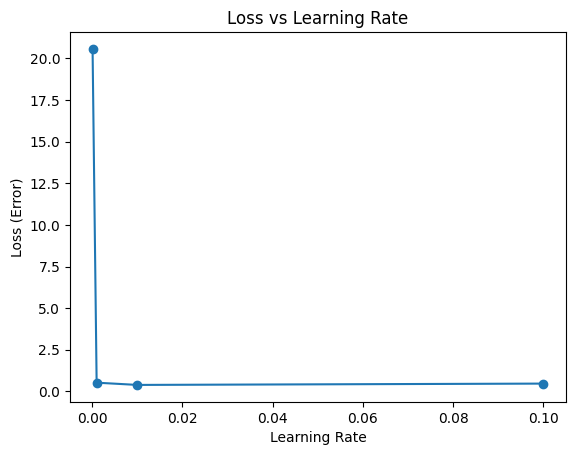

In [16]:
import matplotlib.pyplot as plt

plt.plot(learning_rates, losses, marker='o')
plt.xlabel("Learning Rate")
plt.ylabel("Loss (Error)")
plt.title("Loss vs Learning Rate")
plt.show()

Observation-
* The loss decreases for moderate learning rates, showing better model performance.
* Very small or very large learning rates result in higher loss due to slow or unstable learning.

Implement an MLP using the Gradient Descent algorithm, and analyze the convergence behavior and performance of the network.

In [17]:
from sklearn.neural_network import MLPClassifier

model = MLPClassifier(hidden_layer_sizes=(10,), 
                      learning_rate_init=0.01,
                      max_iter=200,
                      verbose=True)

model.fit(X_train, y_train)

Iteration 1, loss = 19.02083800
Iteration 2, loss = 15.14191647
Iteration 3, loss = 14.59025214
Iteration 4, loss = 12.10602992
Iteration 5, loss = 11.52079187
Iteration 6, loss = 10.86696962
Iteration 7, loss = 8.10845516
Iteration 8, loss = 7.21309624
Iteration 9, loss = 4.89705110
Iteration 10, loss = 3.81637927
Iteration 11, loss = 2.32742075
Iteration 12, loss = 1.48645726
Iteration 13, loss = 1.28343292
Iteration 14, loss = 1.21290891
Iteration 15, loss = 1.17095193
Iteration 16, loss = 1.14476223
Iteration 17, loss = 1.08381936
Iteration 18, loss = 1.00220411
Iteration 19, loss = 0.92477853
Iteration 20, loss = 0.89176878
Iteration 21, loss = 0.85396748
Iteration 22, loss = 0.83278059
Iteration 23, loss = 0.79425074
Iteration 24, loss = 0.75841705
Iteration 25, loss = 0.74303090
Iteration 26, loss = 0.71193666
Iteration 27, loss = 0.69477529
Iteration 28, loss = 0.67815312
Iteration 29, loss = 0.66563180
Iteration 30, loss = 0.63801667
Iteration 31, loss = 0.62277463
Iteration 3

MLPClassifier(hidden_layer_sizes=(10,), learning_rate_init=0.01, verbose=True)

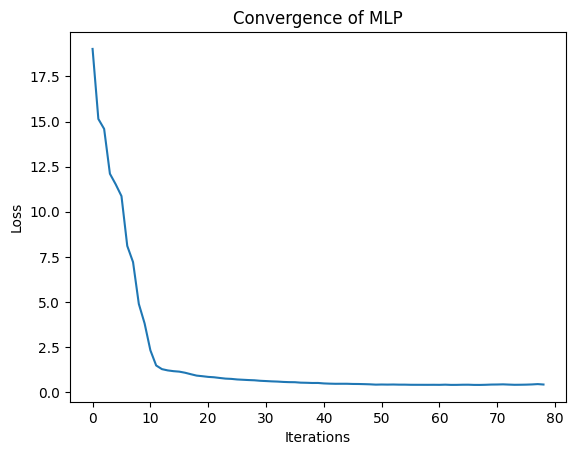

In [18]:
import matplotlib.pyplot as plt

plt.plot(model.loss_curve_)
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.title("Convergence of MLP")
plt.show()

Observation
* The loss decreases over iterations, indicating that the model is learning and converging.
* After several iterations, the loss stabilizes, showing that the model has reached optimal weights.

Perceptron using sklearn + analyze learning rate effect

In [19]:
from sklearn.linear_model import Perceptron
from sklearn.metrics import accuracy_score

learning_rates = [0.0001, 0.001, 0.01, 0.1]
accuracies = []

for lr in learning_rates:
    model = Perceptron(eta0=lr, max_iter=1000)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)

    accuracies.append(acc)
    print(f"Learning Rate: {lr} -> Accuracy: {acc}")

Learning Rate: 0.0001 -> Accuracy: 0.5760869565217391
Learning Rate: 0.001 -> Accuracy: 0.5760869565217391
Learning Rate: 0.01 -> Accuracy: 0.5760869565217391
Learning Rate: 0.1 -> Accuracy: 0.5760869565217391


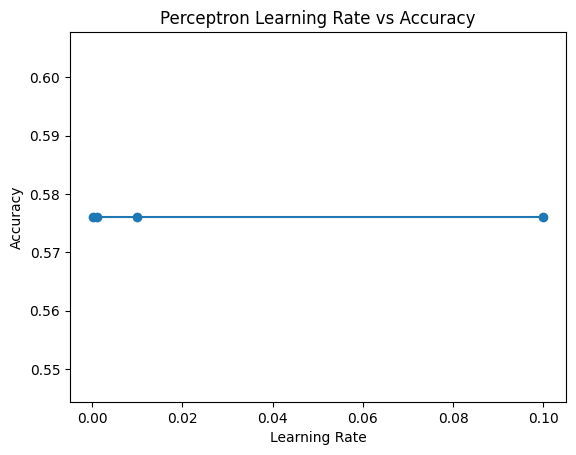

In [20]:
import matplotlib.pyplot as plt

plt.plot(learning_rates, accuracies, marker='o')
plt.xlabel("Learning Rate")
plt.ylabel("Accuracy")
plt.title("Perceptron Learning Rate vs Accuracy")
plt.show()

Observation
* Moderate learning rates give better accuracy, while very small or large values reduce performance.
* Learning rate affects how quickly and effectively the perceptron converges.

Implement MLP on any dataset and explore what particular parameters works for it such as learning rate, iterations etc

In [22]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

configs = [
    {"lr": 0.001, "layers": (5,), "iter": 300},
    {"lr": 0.01, "layers": (10,), "iter": 500},
    {"lr": 0.01, "layers": (20,), "iter": 800},
    {"lr": 0.1, "layers": (10, 5), "iter": 500}
]

for c in configs:
    model = MLPClassifier(hidden_layer_sizes=c["layers"],
                          learning_rate_init=c["lr"],
                          max_iter=c["iter"])
    
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    
    print(f"Config: {c} -> Accuracy: {acc}")

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


Config: {'lr': 0.001, 'layers': (5,), 'iter': 300} -> Accuracy: 0.8369565217391305
Config: {'lr': 0.01, 'layers': (10,), 'iter': 500} -> Accuracy: 0.8206521739130435
Config: {'lr': 0.01, 'layers': (20,), 'iter': 800} -> Accuracy: 0.8315217391304348
Config: {'lr': 0.1, 'layers': (10, 5), 'iter': 500} -> Accuracy: 0.5706521739130435


Improved

In [28]:
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

# 🔹 Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 🔹 Different configurations (improved)
configs = [
    {"lr": 0.001, "layers": (10,), "iter": 500},
    {"lr": 0.001, "layers": (50,25), "iter": 1000},
    {"lr": 0.0005, "layers": (100,50), "iter": 1500},
    {"lr": 0.01, "layers": (30,15), "iter": 800}
]

# 🔹 Training loop
for c in configs:
    model = MLPClassifier(
        hidden_layer_sizes=c["layers"],
        learning_rate_init=c["lr"],
        max_iter=c["iter"],
        solver='adam',          # better optimizer
        alpha=0.0001,           # regularization
        random_state=42
    )
    
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    
    acc = accuracy_score(y_test, y_pred)
    
    print(f"Config: {c} -> Accuracy: {acc}")

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


Config: {'lr': 0.001, 'layers': (10,), 'iter': 500} -> Accuracy: 0.8260869565217391
Config: {'lr': 0.001, 'layers': (50, 25), 'iter': 1000} -> Accuracy: 0.842391304347826
Config: {'lr': 0.0005, 'layers': (100, 50), 'iter': 1500} -> Accuracy: 0.8260869565217391
Config: {'lr': 0.01, 'layers': (30, 15), 'iter': 800} -> Accuracy: 0.8315217391304348


Observation
* The performance of the MLP varies with learning rate, network size, and iterations, highlighting the importance of parameter tuning.
* Moderate learning rates with balanced architectures and early stopping provide the best accuracy and stable convergence

In [30]:
import os
import cv2
import numpy as np

folder = "/kaggle/input/datasets/xiaose/cityscapes/Cityspaces/images/val/munster"

X = []
y = []

for i, file in enumerate(os.listdir(folder)):
    if file.endswith(".png"):
        img_path = os.path.join(folder, file)
        
        img = cv2.imread(img_path)
        img = cv2.resize(img, (32, 32))   # reduce size
        
        X.append(img.flatten())
        y.append(i % 2)   # fake labels (just for demo)

X = np.array(X)
y = np.array(y)

print("Data shape:", X.shape)

Data shape: (174, 3072)


In [34]:
import os
import cv2
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

# 🔹 Base path
base_path = "/kaggle/input/datasets/xiaose/cityscapes/Cityspaces/images/val"

# 🔹 Get available folders automatically
cities = os.listdir(base_path)
print("Available cities:", cities)

# 🔹 Take first 2 cities (for classification)
cities = cities[:2]
print("Using cities:", cities)

X = []
y = []

# 🔹 Load images
for label, city in enumerate(cities):
    folder = os.path.join(base_path, city)

    for file in os.listdir(folder):
        if file.endswith(".png"):
            img_path = os.path.join(folder, file)
            
            img = cv2.imread(img_path)
            img = cv2.resize(img, (32, 32))   # resize
            
            X.append(img.flatten())
            y.append(label)

# 🔹 Convert to numpy
X = np.array(X)
y = np.array(y)

print("Data shape:", X.shape)

# 🔹 Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 🔹 Train model
model = MLPClassifier(hidden_layer_sizes=(50,), max_iter=300)
model.fit(X_train, y_train)

# 🔹 Predict
y_pred = model.predict(X_test)

# 🔹 Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

Available cities: ['munster', 'lindau', 'frankfurt']
Using cities: ['munster', 'lindau']
Data shape: (233, 3072)
Accuracy: 0.2978723404255319


Observation-
Since MLP is not for image classification so it is designed more for tabular data 
due to this we got very less accuracy


In [36]:
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

# 🔹 Load dataset (offline)
data = load_digits()

X = data.data
y = data.target

# 🔹 Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 🔹 Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 🔹 Model
model = MLPClassifier(
    hidden_layer_sizes=(100,),
    learning_rate_init=0.001,
    max_iter=300
)

# 🔹 Train
model.fit(X_train_scaled, y_train)

# 🔹 Predict
y_pred = model.predict(X_test_scaled)

# 🔹 Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9722222222222222


Observation
* The MLP model successfully learned handwritten digit patterns and achieved high accuracy on the MNIST dataset.
* Proper scaling and sufficient hidden neurons improve performance and convergence.